# SMS Spam Detection

## 1 · Libraries

In [46]:
import re
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
print("✅ Setup ready")

✅ Setup ready


## 2 · Configuration

In [47]:
DATA_PATH   = Path('Dataset/spam.csv')
DATA2_PATH  = Path('Dataset/combined_dataset.csv')
DATA3_PATH  = Path('Dataset/combined_dataset.csv')

OUTPUT_DIR  = Path('Saved_model')
RESULTS_DIR = Path('results')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 3 · Download NLTK Data

In [48]:
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(resource, quiet=True)
print("✅ NLTK ready")

✅ NLTK ready


## 4 · Load & Merge Datasets

In [49]:
print('⏳ Loading datasets...')

def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding='latin-1', usecols=[0, 1],
                     names=['label', 'text'], header=0)
    df = df.dropna(subset=['text'])
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df['text']  = df['text'].astype(str)
    return df


# ✔️ FIXED FOR YOUR DATASETS (v1 / v2 format)
def load_v1_v2(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    print(f"{path.name} columns:", df.columns)  # debug only

    df = df[['v1', 'v2']].copy()
    df.columns = ['label', 'text']

    df = df.dropna(subset=['text'])
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df['text']  = df['text'].astype(str)

    return df


def normalize_label(label: str) -> str:
    label = str(label).lower().strip()
    if label in ['spam', '1', 'junk', 'scam', 'fraud']:
        return 'spam'
    return 'ham'


# ── Load datasets ─────────────────────────────
df1 = load_data(DATA_PATH)
df2 = load_v1_v2(DATA2_PATH)
df3 = load_v1_v2(DATA3_PATH)

# ── Normalize labels ──────────────────────────
for d in [df1, df2, df3]:
    d['label'] = d['label'].apply(normalize_label)

# ── Merge ─────────────────────────────────────
df = pd.concat([df1, df2, df3], ignore_index=True)

print(f'\nShape before cleaning : {df.shape}')
print(df['label'].value_counts())

⏳ Loading datasets...
combined_dataset.csv columns: Index(['v1', 'v2'], dtype='object')
combined_dataset.csv columns: Index(['v1', 'v2'], dtype='object')

Shape before cleaning : (27494, 2)
label
ham     21935
spam     5559
Name: count, dtype: int64


## 5 · Cleaning Data

In [50]:
def basic_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != ""]

df['tmp_clean'] = df['text'].apply(basic_clean)

before = len(df)
df = df.drop_duplicates(subset='tmp_clean')
after = len(df)

print(f'🧹 Removed {before - after} duplicates')

df['word_count'] = df['tmp_clean'].str.split().str.len()
df = df[df['word_count'] > 2]

df = df.drop(columns=['tmp_clean', 'word_count'])

print(f'Shape after cleaning : {df.shape}')
print(df['label'].value_counts())

🧹 Removed 17236 duplicates
Shape after cleaning : (10178, 2)
label
ham     7940
spam    2238
Name: count, dtype: int64


## 5.1 EDA

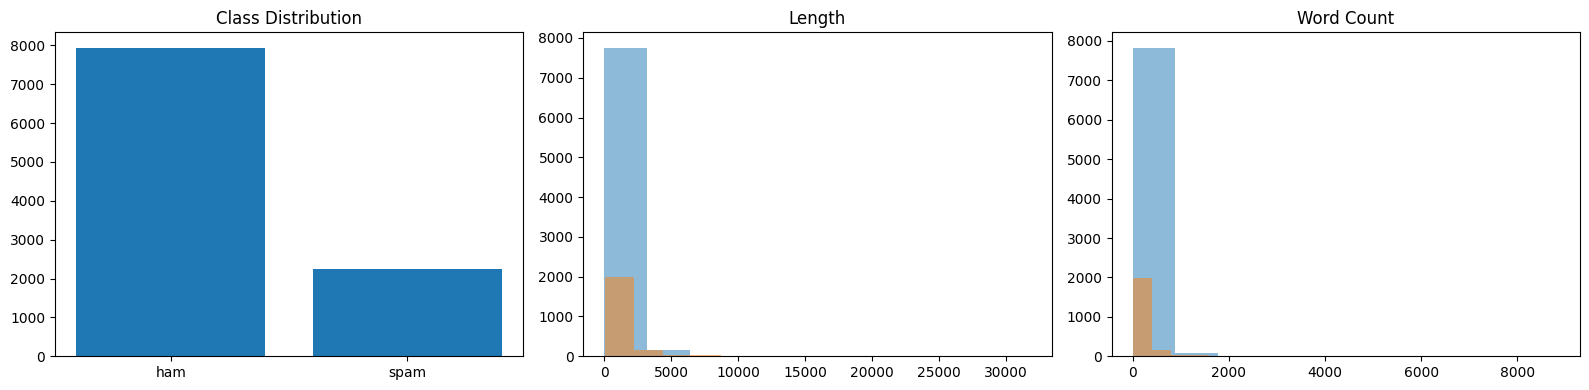

In [51]:
df['text_len']   = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values)
axes[0].set_title('Class Distribution')

axes[1].hist(df[df['label']=='ham']['text_len'], alpha=0.5)
axes[1].hist(df[df['label']=='spam']['text_len'], alpha=0.5)
axes[1].set_title('Length')

axes[2].hist(df[df['label']=='ham']['word_count'], alpha=0.5)
axes[2].hist(df[df['label']=='spam']['word_count'], alpha=0.5)
axes[2].set_title('Word Count')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_plot.png')
plt.show()

## 6 · Text Preprocessing

In [52]:
STOP_WORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

## 7 · Train / Test Split

In [53]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

X = df['clean_text']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 8 · TF-IDF Vectorisation

In [54]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

## 9 ·Models

In [55]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Linear SVC': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=200)
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    results[name] = {
        'model': model,
        'preds': preds,
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

    print(name, results[name])

Naive Bayes {'model': MultinomialNB(), 'preds': array([0, 0, 0, ..., 0, 0, 0]), 'accuracy': 0.956286836935167, 'f1': 0.8954171562867215}
Logistic Regression {'model': LogisticRegression(max_iter=2000), 'preds': array([0, 0, 0, ..., 0, 0, 0]), 'accuracy': 0.9425343811394892, 'f1': 0.8560885608856088}
Linear SVC {'model': LinearSVC(), 'preds': array([0, 0, 0, ..., 0, 0, 0]), 'accuracy': 0.9641453831041258, 'f1': 0.9146198830409357}
Random Forest {'model': RandomForestClassifier(n_estimators=200), 'preds': array([0, 0, 0, ..., 0, 0, 0]), 'accuracy': 0.956286836935167, 'f1': 0.8934131736526946}


## 10 · Model Comparison

In [56]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
print("Best:", best_model_name)

Best: Linear SVC


## 11 · Confusion Matrices

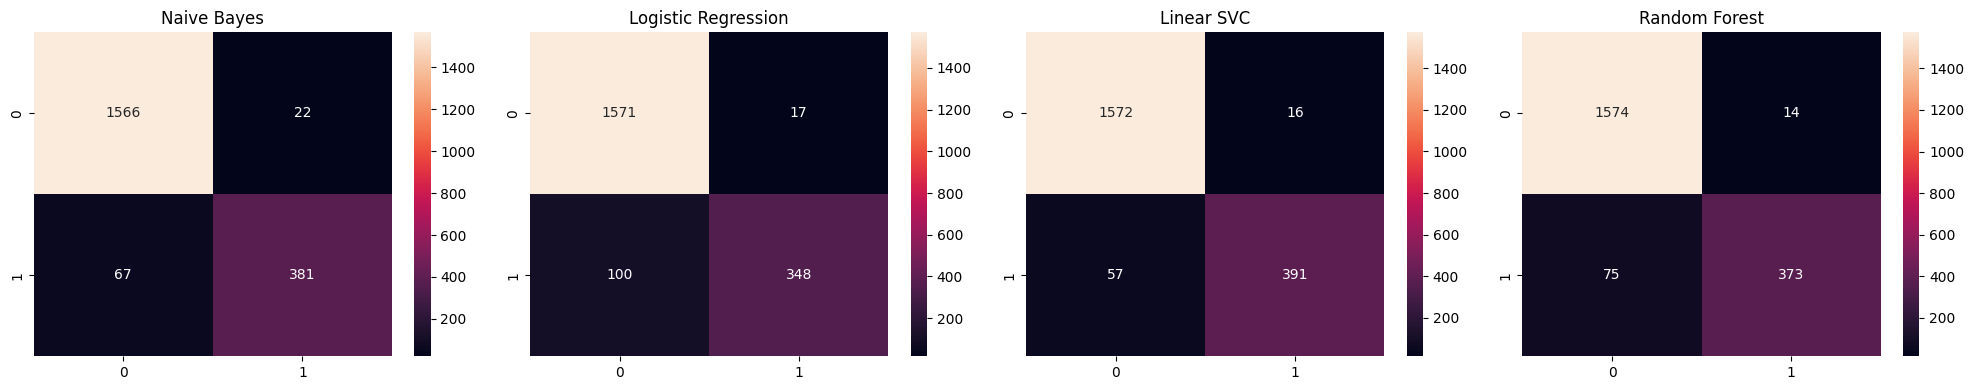

In [57]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results),4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png')
plt.show()

## 12 · ROC Curves

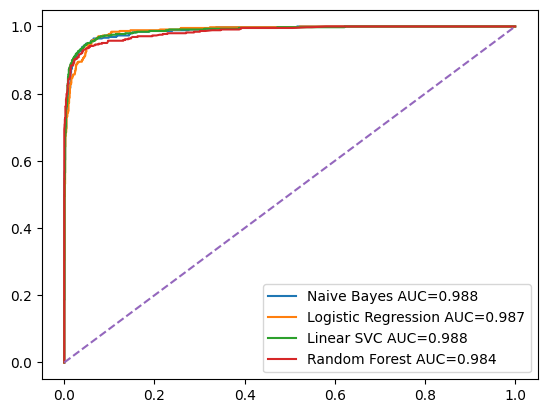

In [58]:
fig, ax = plt.subplots()

for name, res in results.items():
    model = res['model']
    
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test_vec)[:,1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test_vec)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

ax.plot([0,1],[0,1],'--')
ax.legend()

plt.savefig(RESULTS_DIR / 'roc.png')
plt.show()

## 13 · Best Model — Classification Report

In [59]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best = results[best_model_name]

print(f'\n🏆 Best model: {best_model_name}')
print('\n=== Classification Report ===')
print(classification_report(y_test, best['preds'], target_names=le.classes_))


🏆 Best model: Linear SVC

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98      1588
        spam       0.96      0.87      0.91       448

    accuracy                           0.96      2036
   macro avg       0.96      0.93      0.95      2036
weighted avg       0.96      0.96      0.96      2036



## 14 · Cross-Validation (LogisticRegression)

In [60]:
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
        stop_words='english'
    )),
    ('clf', LogisticRegression(max_iter=2000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(
    cv_pipeline,
    df['clean_text'],
    df['label_enc'],
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

print(f'5-Fold CV F1 per fold : {np.round(cv_f1, 4)}')
print(f'Mean F1               : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-Fold CV F1 per fold : [0.8536 0.8429 0.8403 0.8426 0.8128]
Mean F1               : 0.8384 ± 0.0136


## 16 · Save Model & Encoder

In [61]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']

pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', best_model)
])

joblib.dump(pipeline, OUTPUT_DIR / 'spam_pipeline.pkl')
joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')

print("✅ Model saved")

✅ Model saved


## 17 · Results Summary

In [62]:
print('=' * 55)
print('        SMS SPAM DETECTION — SUMMARY')
print('=' * 55)

print(f'  Dataset size     : {len(df):,}')
print(f'  Spam / Ham       : {(df["label"]=="spam").sum():,} / {(df["label"]=="ham").sum():,}')
print(f'  Best model       : {best_model_name}')
print(f'  Accuracy         : {best["accuracy"]:.4f}')
print(f'  F1 Score         : {best["f1"]:.4f}')
print(f'  CV F1 (5-fold)   : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

print('-' * 55)
print(f'  Saved model      : {OUTPUT_DIR / "spam_pipeline.pkl"}')
print(f'  Saved encoder    : {OUTPUT_DIR / "label_encoder.pkl"}')

print('-' * 55)
print(f'  Plots saved to   : {RESULTS_DIR}/')

for p in sorted(RESULTS_DIR.glob('*.png')):
    print(f'    · {p.name}')

print('=' * 55)

        SMS SPAM DETECTION — SUMMARY
  Dataset size     : 10,178
  Spam / Ham       : 2,238 / 7,940
  Best model       : Linear SVC
  Accuracy         : 0.9641
  F1 Score         : 0.9146
  CV F1 (5-fold)   : 0.8384 ± 0.0136
-------------------------------------------------------
  Saved model      : Saved_model\spam_pipeline.pkl
  Saved encoder    : Saved_model\label_encoder.pkl
-------------------------------------------------------
  Plots saved to   : results/
    · confusion_matrices.png
    · eda_plot.png
    · roc.png
